### 차트 작성 시 한글 깨짐 방지를 위한 koreanize-matplotlib 설치

In [1]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 32.3 MB/s eta 0:00:00


### 라이브러리 import

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

### 1. 데이터 로드 및 분할

In [12]:
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
feature_names = diabetes.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

### 2. 데이터 전처리

In [13]:
X_features = df[feature_names].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)


표준화 후 평균(각 변수): [-0.  0.  0. -0.  0. -0. -0.  0.  0. -0.]
표준화 후 표준편차(각 변수): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 3. 최적의 K 탐색

In [14]:
k_range = range(2, 11)  # 2~10개 군집
sil_scores = []

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,          # 버전 호환성 위해 명시
        max_iter=300
    )
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"k = {k:2d}, 실루엣 점수 = {score:.4f}")

# 최적 k 선택
best_k = k_range[int(np.argmax(sil_scores))]
best_score = max(sil_scores)

print("\n=== 실루엣 기준 최적 k 선택 결과 ===")
print(f"최적 군집 수 k = {best_k}, 실루엣 점수 = {best_score:.4f}")

k =  2, 실루엣 점수 = 0.2370
k =  3, 실루엣 점수 = 0.1535
k =  4, 실루엣 점수 = 0.1372
k =  5, 실루엣 점수 = 0.1467
k =  6, 실루엣 점수 = 0.1430
k =  7, 실루엣 점수 = 0.1433
k =  8, 실루엣 점수 = 0.1401
k =  9, 실루엣 점수 = 0.1374
k = 10, 실루엣 점수 = 0.1333

=== 실루엣 기준 최적 k 선택 결과 ===
최적 군집 수 k = 2, 실루엣 점수 = 0.2370


### 4. 최적 K로 kmeans 재학습

In [15]:
# 4. 최적 k로 KMeans 재학습
best_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10,
    max_iter=300
)
cluster_labels = best_kmeans.fit_predict(X_scaled)

df['cluster'] = cluster_labels

### 5. 군집별 요약

In [19]:
print("군집별 샘플 수 ")
display(df['cluster'].value_counts().sort_index())

군집별 샘플 수 


,count
cluster,
0,214
1,228


In [20]:
print("군집별 타깃(질병 진행도) 평균")
display(df.groupby('cluster')['target'].mean())

군집별 타깃(질병 진행도) 평균


,target
cluster,
0,113.551402
1,188.346491


### 6. PCA 2차원으로 차원 축소 후 군집 시각화

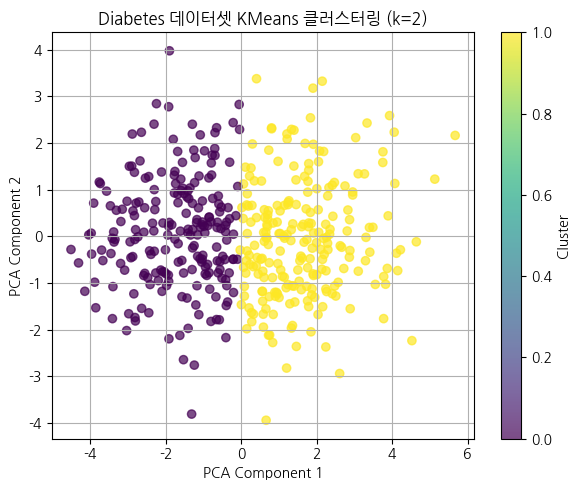

In [23]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    alpha=0.7
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(f"Diabetes 데이터셋 KMeans 클러스터링 (k={best_k})")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()